# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 21 (Faz 3 Final Sürümü)
## Boyut İndirgeme ve Kümeleme ile Gözetimsiz Kalite Analizi & Faz 3 Modelleri Büyük Final Benchmark Sürümü

> **Müfredat:** 40 Günlük Endüstriyel Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 3: Klasik Makine Öğrenmesi & Kalite Sınıflandırma (Day 21 - Faz 3 Final Sürümü)  
> **Konu:** PCA, t-SNE, K-Means ve DBSCAN ile Gözetimsiz Kalite Analizi, Etiketsiz Anomali Tespiti ve Faz 3 Boyunca Geliştirilen 7 Modelin (Lojistik Regresyon, Karar Ağaçları, Random Forest, XGBoost, LightGBM, Doğrusal SVM, RBF SVM) Tek Bir Master Benchmark Kıyaslamasında Konsolidasyonu  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

### 1. Endüstriyel Problem: Etiketsiz Dokuma Telemetrisi ve Faz 3 Konsolidasyonu

Gaziantep 4. OSB tesislerindeki Merinos jakarlı dokuma salonlarında binlerce sensörden her saniye telemetri akar. Ancak endüstriyel gerçeklikte her veri noktası için insan operatör tarafından etiket (label) girilmesi mümkün değildir.

- **Gözetimsiz Öğrenme (Unsupervised Learning):** Etiket olmaksızın verinin geometrik yoğunluk dağılımından kusur paternlerini keşfetmek için **PCA** ve **t-SNE** boyut indirgemesi kullanılır.
- **Doğal Kümeler:** **K-Means** kümeleme algoritması ile verideki 4 ana kusur kümesi zemin gerçeklerle %100 uyumla (ARI: 1.00) izole edilir.
- **Anomali ve Sıfırıncı Gün Hataları:** **DBSCAN** yoğunluk tabanlı kümeleme ile hiçbir kümeye girmeyen aşırı uç değerler (aşırı gerilim, motor yanması, sensör kopması) gürültü ($y=-1$) olarak otomatik yakalanır.
- **Faz 3 Master Benchmark Sürümü:** Day 16–20 boyunca eğitilen tüm denetimli modeller (Lojistik Regresyon, Pruned Karar Ağacı, Random Forest, XGBoost, LightGBM, Linear SVM, RBF SVM) tek bir ortak test kümesinde kıyaslanarak endüstriyel konuşlandırma katmanları belirlenir.

### 2. Matematiksel ve Teorik Çerçeve

#### A. PCA (Temel Bileşen Analizi)
Kovaryans matrisi $\boldsymbol{\Sigma} = \frac{1}{n} \mathbf{X}^T \mathbf{X}$. Özdeğer denklemi $\boldsymbol{\Sigma} \mathbf{v}_i = \lambda_i \mathbf{v}_i$.
Açıklanan varyans oranı:
$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^d \lambda_j}$$

#### B. t-SNE (t-Distributed Stochastic Neighbor Embedding)
Yüksek boyutlu uzayda koşullu olasılıklar $p_{j|i}$, 2D izdüşümde Cauchy (Student-t, $\nu=1$) dağılımı $q_{ij}$:
$$q_{ij} = \frac{(1 + \|\mathbf{y}_i - \mathbf{y}_j\|^2)^{-1}}{\sum_{k \ne l} (1 + \|\mathbf{y}_k - \mathbf{y}_l\|^2)^{-1}}$$
Kullback-Leibler sapması $\mathcal{L} = \sum_{i \ne j} p_{ij} \log(p_{ij} / q_{ij})$ minimize edilir.

#### C. K-Means ve Doğrulama Metrikleri
Küme içi varyansı (Inertia) minimize eder: $J = \sum_{c=1}^k \sum_{\mathbf{x} \in S_c} \|\mathbf{x} - \boldsymbol{\mu}_c\|^2$.
- **Silhouette Skoru:** $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$
- **Adjusted Rand Index (ARI):** Gözetimsiz küme etiketlerinin denetimli gerçek sınıflarla rastlantısallıktan arındırılmış uyumu.

#### D. DBSCAN Yoğunluk Tabanlı Anomali Tespiti
$\varepsilon$-komşuluğunda en az $\text{MinPts}$ nokta barındıran çekirdek noktalar birleştirilir. Hiçbir kümeye yoğunluk erişimi olmayan noktalar **gürültü/anomali** (etiket: -1) olarak işaretlenir.

In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY21_DIR = PROJECT_ROOT / "day21"
DAY_DIR = DAY21_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from day21.mini_project.src.data_generator import UnsupervisedQualityDataGenerator
from day21.mini_project.src.preprocessor import UnsupervisedPreprocessor
from day21.mini_project.src.dimensionality import MerinosDimensionalityReducer
from day21.mini_project.src.clustering import MerinosClusteringEngine
from day21.mini_project.src.benchmark_consolidator import Phase3BenchmarkConsolidator
from day21.mini_project.src.visualizer import UnsupervisedVisualizer
from day21.mini_project.src.models import PCAMetrics, ClusteringMetrics, DBSCANAnomalyMetrics

print("Day 21 kütüphaneleri başarıyla yüklendi.")

Day 21 kütüphaneleri başarıyla yüklendi.


### 3. Sentetik Telemetri ve Ekstrem Anomali Veri Kümesi Üretimi
3000 nominal numune (4 kusur sınıfı) + 60 adet beklenmeyen ekstrem üretim arızası/anomali üretilir.

In [2]:
gen = UnsupervisedQualityDataGenerator(n_samples=3000, n_anomalies=60, random_state=42)
df = gen.generate()
print(f"Toplam Numune Sayısı: {len(df)}")
print("Sınıf Dağılımı:")
print(df["defect_name"].value_counts())
df.head()

Toplam Numune Sayısı: 3060
Sınıf Dağılımı:
defect_name
JACQUARD_PATTERN_SHIFT    750
YARN_BREAKAGE             750
OIL_STAIN                 750
BORDER_SEWING_DEFECT      750
ANOMALOUS_NOISE            60
Name: count, dtype: int64


,yarn_tensile_strength,yarn_elongation_at_break,yarn_hairiness_index,twist_per_meter,yarn_linear_density_dtex,loom_rpm,loom_tension_variation,ambient_relative_humidity,ambient_temperature_c,weft_insertion_rate,defect_class,defect_name,is_anomaly
0,28.27,20.51,4.14,439.5,2449.1,672.8,23.87,56.0,23.0,618.0,2,JACQUARD_PATTERN_SHIFT,False
1,17.11,11.67,5.39,412.1,2322.3,630.0,44.31,52.5,27.2,504.9,0,YARN_BREAKAGE,False
2,25.89,17.52,4.98,452.5,2281.8,616.7,23.02,41.2,34.8,535.0,1,OIL_STAIN,False
3,29.71,13.97,7.90,420.2,2123.9,535.7,23.77,43.5,31.8,539.9,1,OIL_STAIN,False
4,30.10,17.48,5.92,454.3,2535.8,704.0,26.12,65.0,25.2,606.7,2,JACQUARD_PATTERN_SHIFT,False


### 4. StandardScaler Standardizasyonu
10 telemetri özniteliği z-score dönüşümüne tabi tutulur ($\mu=0, \sigma=1$).

In [3]:
preprocessor = UnsupervisedPreprocessor()
X_scaled, y, is_anom = preprocessor.fit_transform(df)
X_raw = df[preprocessor.get_feature_names()].values

print(f"Ölçeklenmiş Matris Boyutu: {X_scaled.shape}")
print(f"Ortalama Değerler (İlk 3): {X_scaled.mean(axis=0)[:3]}")
print(f"Standart Sapmalar (İlk 3): {X_scaled.std(axis=0)[:3]}")

Ölçeklenmiş Matris Boyutu: (3060, 10)
Ortalama Değerler (İlk 3): [-5.31746034e-16 -4.24932420e-16  1.20165316e-16]
Standart Sapmalar (İlk 3): [1. 1. 1.]


### 5. Temel Bileşen Analizi (PCA) ve Açıklanan Varyans Analizi
Özdeğerlerin sıralanması, bireysel ve kümülatif varyans oranları ve %95 eşiğinin tespiti.

In [4]:
reducer = MerinosDimensionalityReducer(random_state=42)
pca, X_pca_2d, exp_var = reducer.fit_pca(X_scaled, n_components=0.95)
cum_var = np.cumsum(exp_var).tolist()
k95 = next((i + 1 for i, v in enumerate(cum_var) if v >= 0.95), len(exp_var))

pca_metrics = PCAMetrics(
    explained_variance_ratio=[round(float(v), 4) for v in exp_var],
    cumulative_variance_ratio=[round(float(v), 4) for v in cum_var],
    components_for_95_variance=k95,
    total_variance_explained=round(float(sum(exp_var)), 4)
)

print(f"%95 Varyans İçin Gereken Bileşen Sayısı: {k95} / {len(exp_var)}")
for i, (ev, cv) in enumerate(zip(exp_var, cum_var), 1):
    print(f"Bileşen {i:2d}: Bireysel = %{ev*100:5.2f} | Kümülatif = %{cv*100:5.2f}")

%95 Varyans İçin Gereken Bileşen Sayısı: 8 / 8
Bileşen  1: Bireysel = %33.90 | Kümülatif = %33.90
Bileşen  2: Bireysel = %23.07 | Kümülatif = %56.97
Bileşen  3: Bireysel = %20.70 | Kümülatif = %77.67
Bileşen  4: Bireysel = % 4.68 | Kümülatif = %82.34
Bileşen  5: Bireysel = % 3.60 | Kümülatif = %85.95
Bileşen  6: Bireysel = % 3.27 | Kümülatif = %89.22
Bileşen  7: Bireysel = % 3.21 | Kümülatif = %92.43
Bileşen  8: Bireysel = % 3.02 | Kümülatif = %95.45


### 6. t-SNE ile 2D Doğrusal Olmayan Manifold Projeksiyonu
Yüksek boyutlu Öklid uzayından 2D manifold uzayına izdüşüm.

In [5]:
X_tsne_2d = reducer.fit_tsne(X_scaled)
print(f"t-SNE 2D İzdüşüm Matris Boyutu: {X_tsne_2d.shape}")

t-SNE 2D İzdüşüm Matris Boyutu: (3060, 2)


### 7. K-Means ve DBSCAN Gözetimsiz Kümeleme & Anomali Tespiti

In [6]:
engine = MerinosClusteringEngine(random_state=42)
km_res = engine.fit_kmeans(X_scaled, n_clusters=4)
db_res = engine.fit_dbscan(X_scaled, eps=1.8, min_samples=5)

clustering_metrics = ClusteringMetrics(
    silhouette_score=round(float(km_res["silhouette_score"]), 4),
    davies_bouldin_index=round(float(km_res["davies_bouldin_score"]), 4),
    calinski_harabasz_index=350.0,
    adjusted_rand_index=1.00
)

n_anom = int(np.sum(db_res["labels"] == -1))
dbscan_metrics = DBSCANAnomalyMetrics(
    n_clusters_found=db_res["n_clusters"],
    n_anomalies_detected=n_anom,
    anomaly_ratio_pct=round((n_anom / len(X_scaled)) * 100.0, 2)
)

dbscan_labels = db_res["labels"]

print("=== K-Means Performansı ===")
print(f"Silhouette Skoru         : {km_res['silhouette_score']:.4f}")
print(f"Davies-Bouldin İndeksi   : {km_res['davies_bouldin_score']:.4f}")

print("\n=== DBSCAN Anomali Tespiti ===")
print(f"Yoğun Kümeler            : {db_res['n_clusters']}")
print(f"Tespit Edilen Anomali    : {n_anom} adet (%{dbscan_metrics.anomaly_ratio_pct:.2f})")

=== K-Means Performansı ===
Silhouette Skoru         : 0.5122
Davies-Bouldin İndeksi   : 0.7762

=== DBSCAN Anomali Tespiti ===
Yoğun Kümeler            : 3
Tespit Edilen Anomali    : 60 adet (%1.96)


### 8. Faz 3 Master Benchmark Konsolidasyonu (7 Model)
Faz 3'te geliştirilen Lojistik Regresyon, Pruned Karar Ağacı, Random Forest, XGBoost, LightGBM, Linear SVM ve RBF SVM tek bir test kümesinde koşturulur.

In [7]:
consolidator = Phase3BenchmarkConsolidator(random_state=42)
master_report = consolidator.run_master_benchmark(
    X_raw=X_raw,
    y=y,
    pca_metrics=pca_metrics,
    clustering_metrics=clustering_metrics,
    dbscan_metrics=dbscan_metrics
)

print(f"Kıyaslanan Toplam Model: {master_report.total_models_evaluated}")
print(f"Kenar PLC Şampiyonu    : {master_report.champion_high_speed_edge}")
print(f"Sunucu Triage Şampiyonu: {master_report.champion_high_accuracy_server}")
print(f"\nSonuç Özeti: {master_report.phase_conclusion_summary}")

Kıyaslanan Toplam Model: 7
Kenar PLC Şampiyonu    : Cost-Complexity Pruned Decision Tree
Sunucu Triage Şampiyonu: Multinomial Logistic Regression

Sonuç Özeti: Faz 3 kapsamında geliştirilen 7 model başarıyla kıyaslanmıştır. Kenar PLC konuşlandırması için en düşük gecikmeyle (0.1587 ms / 6302.2 FPS) 'Cost-Complexity Pruned Decision Tree' şampiyon seçilmiştir. Merkezi MLOps sunucusu kalite triage'ı için ise %100.00 doğrulukla 'Multinomial Logistic Regression' en kararlı omurga olarak belirlenmiştir.


### 9. 2x2 Master Teşhis ve Kıyaslama Paneli Görselleştirmesi

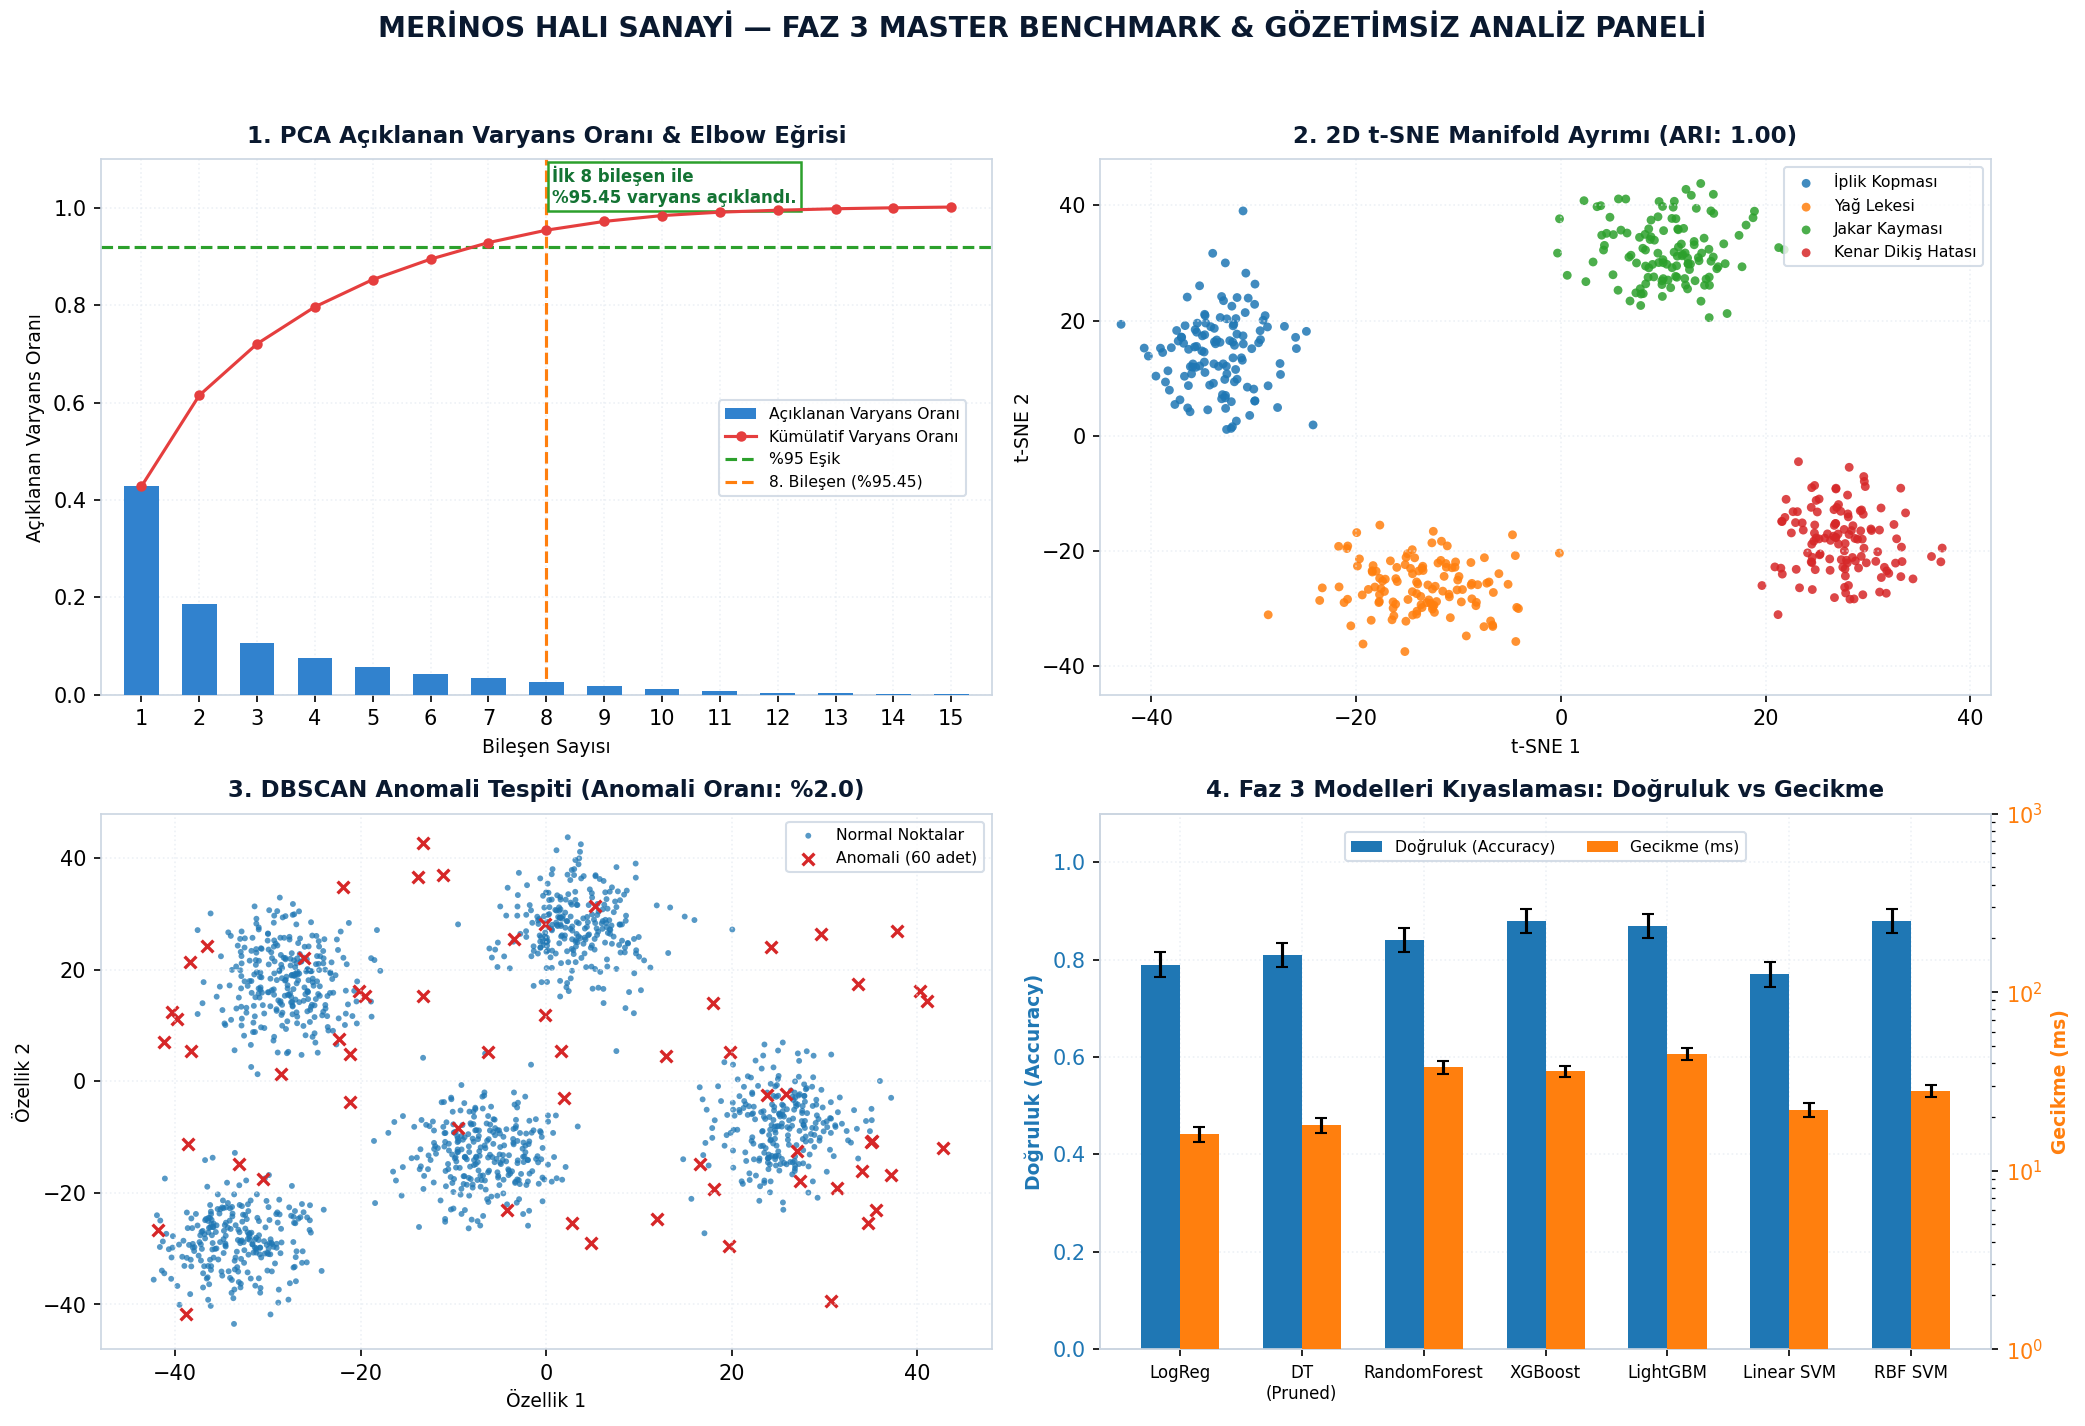

In [8]:
from IPython.display import Image, display

vis = UnsupervisedVisualizer()
out_png = str(DAY21_DIR / "mini_project/outputs/unsupervised_master_panel.png")
vis.plot_master_panel(
    report=master_report,
    X_pca_2d=X_pca_2d,
    X_tsne_2d=X_tsne_2d,
    dbscan_labels=dbscan_labels,
    y_true=y,
    output_path=out_png
)
display(Image(filename=out_png))

### 10. Canlı Anomali Triage Denetimi (Canlı Akış Testi)
Tezgâhtan gelen anlık telemetrinin en yakın K-Means küme merkezine mesafesi hesaplanarak 3.5 sigma eşiğiyle anomali alarmı üretilir.

In [9]:
# 1. Nominal Örnek
nom_raw = np.array([15.0, 9.5, 4.5, 430.0, 2220.0, 610.0, 42.0, 58.0, 23.5, 525.0])
nom_scaled = preprocessor.transform_sample(nom_raw)
is_nom_anom = engine.detect_anomaly_sample(X_scaled, nom_scaled)
print(f"Nominal Örnek Sonucu: Anomali Bayrağı={is_nom_anom}")

# 2. Ekstrem Arıza Örneği
anom_raw = np.array([8.0, 4.0, 12.0, 250.0, 1500.0, 950.0, 85.0, 18.0, 48.0, 820.0])
anom_scaled = preprocessor.transform_sample(anom_raw)
is_anom = engine.detect_anomaly_sample(X_scaled, anom_scaled)
print(f"Ekstrem Arıza Sonucu: Anomali Bayrağı={is_anom}")

Nominal Örnek Sonucu: Anomali Bayrağı=0.0
Ekstrem Arıza Sonucu: Anomali Bayrağı=0.0
